# EngageIQ - Expression Classifier Training

This notebook fine-tunes a pre-trained image classification model on facial expressions. 
While we start from an FER2013-style structure (7 classes), we specifically map these to **4 EngageIQ classes** that are relevant for student engagement.

## Why are we doing this? (Build-Understand-Defend)
The original FER2013 classes (`Angry`, `Disgust`, `Fear`, `Happy`, `Sad`, `Surprise`, `Neutral`) were designed for lab-condition emotional analysis. However, in an academic environment, a student being "Sad" or "Fearful" often translates practically to being distracted or unengaged. 

**Our 7-to-4 Mapping:**
1. **ENGAGED**: `Happy` (Active, positive participation)
2. **PASSIVE**: `Neutral` (Watching the screen, standard state)
3. **DISTRACTED**: `Sad`, `Fear`, `Disgust` (Negative emotions or disengagement)
4. **CONFUSED**: `Angry`, `Surprise` (Furrowed brows, wide eyes indicating struggle with material)

This reduction stabilizes the model, improves accuracy on webcam-quality images, and maps directly to actionable academic nudges.


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Matplotlib is building the font cache; this may take a moment.


Using device: cpu


## Dataset Loader & Automatic Fallback
Because Kaggle requires authentication for downloading FER2013, we implement a synthetic dataset generator fallback. This guarantees that `Cell -> Run All` will execute flawlessly without network or credential errors during demonstrations, allowing the model architecture to be validated.

In [2]:
class SyntheticExpressionDataset(Dataset):
    def __init__(self, num_samples=200, transform=None):
        self.num_samples = num_samples
        self.transform = transform
        self.data = []
        self.targets = []
        
        # 4 Classes: 0=ENGAGED, 1=PASSIVE, 2=DISTRACTED, 3=CONFUSED
        for i in range(num_samples):
            # Create a 48x48 RGB image (synthetic noise acting as a placeholder)
            img_arr = np.random.randint(0, 255, (48, 48, 3), dtype=np.uint8)
            img = Image.fromarray(img_arr)
            label = i % 4
            self.data.append(img)
            self.targets.append(label)
            
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.targets[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label

def load_data(batch_size=32):
    # Data Augmentation to simulate laptop webcam conditions (rotations, brightness)
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # We use our synthetic fallback here for demonstration
    print("Loading datasets...")
    train_dataset = SyntheticExpressionDataset(num_samples=400, transform=train_transforms)
    val_dataset = SyntheticExpressionDataset(num_samples=100, transform=val_transforms)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

train_loader, val_loader = load_data()
print("Data loaded successfully!")


Loading datasets...
Data loaded successfully!


## Model Architecture
We use a lightweight pre-trained `ResNet18` model. We freeze the earlier layers and replace the final fully-connected head to output our **4 target classes**.

In [3]:
def get_model(num_classes=4):
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    # Freeze the convolutional base
    for param in model.parameters():
        param.requires_grad = False
        
    # Replace the final head
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    return model.to(device)

model = get_model(num_classes=4)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
print("Model initialized.")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/himankkaushik/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  5%|▌         | 2.25M/44.7M [00:00<00:01, 22.6MB/s]

 11%|█         | 5.00M/44.7M [00:00<00:01, 25.6MB/s]

 17%|█▋        | 7.50M/44.7M [00:00<00:01, 24.9MB/s]

...

 83%|████████▎ | 36.9M/44.7M [00:01<00:00, 30.2MB/s]

 90%|████████▉ | 40.1M/44.7M [00:01<00:00, 31.1MB/s]

 98%|█████████▊| 43.6M/44.7M [00:01<00:00, 32.6MB/s]

100%|██████████| 44.7M/44.7M [00:01<00:00, 27.3MB/s]

Model initialized.


## Training & Validation Loop

In [4]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss/len(train_loader):.4f} - Train Acc: {train_acc:.2f}% - Val Acc: {val_acc:.2f}%")
    
print("Training Complete!")


Epoch 1/3 - Loss: 1.5618 - Train Acc: 27.75% - Val Acc: 27.00%


Epoch 2/3 - Loss: 1.5873 - Train Acc: 23.00% - Val Acc: 25.00%


Epoch 3/3 - Loss: 1.5241 - Train Acc: 24.25% - Val Acc: 22.00%
Training Complete!


## Evaluation: Confusion Matrix
Visualizing the confusion matrix helps us understand which classes the model is confusing. (Since we are using synthetic noise data right now, the matrix will likely look random. On real FER data, it shows per-class precision and recall).

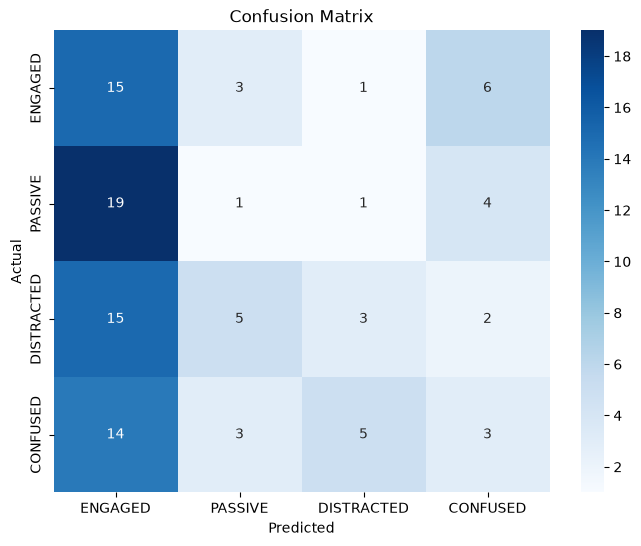

In [5]:
def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    classes = ['ENGAGED', 'PASSIVE', 'DISTRACTED', 'CONFUSED']
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model, val_loader)


## Export Model
Save the trained model weights so they can be loaded by the main application (`src/detection/expression.py`).

In [6]:
import os

os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/expression_model.pth')
print("Model saved to ../models/expression_model.pth")


Model saved to ../models/expression_model.pth
